Market Analysis
These questions investigate general EV trends within all of the United States.

1) Which fifteen states have the most EV registrations? (ArcGIS)
1a) To further this exploration, which states prefer PHEVs versus BEVs in the United States?
2) Which ten counties and cities have the highest amount of EVs, split by PHEVs and BEVs? 
3) How does the count of EVs change over time in the top 10 counties?
4) What are the top ten most popular brands of cars?
5) What are the top ten most popular EV brands, model and model year?
6) How have the number of PHEVs and BEVs changed over the years?
7) How does Minimum and Maximum Electric Ranges change depending on brands?
8) How have Electric Ranges changed over the years?

Dealership Analysis
These questions look at the most popular counties and cities in Washington State, as we saw that the demand for EVs in Washington State was highest.

Which counties represent the strongest EV demand hotspots for dealership placement?
Which regions show a stronger preference for BEVs vs PHEVs, and how should that influence dealership inventory strategy?
Which non-Tesla manufacturers dominate EV demand in high-adoption regions?
Which EV models should dealerships prioritize based on regional demand patterns?
How does electric range vary across EV types and manufacturers, and what does that imply for dealership positioning?
How has electric range improved across model years, and what does this suggest about evolving consumer expectations?

In [2]:
import duckdb 
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
df = pd.read_csv("../data/cleaned/data_wo_fuel.csv")

Market Analysis

**Which fifteen states have the most EV registrations? (w/ GeoPandas)**

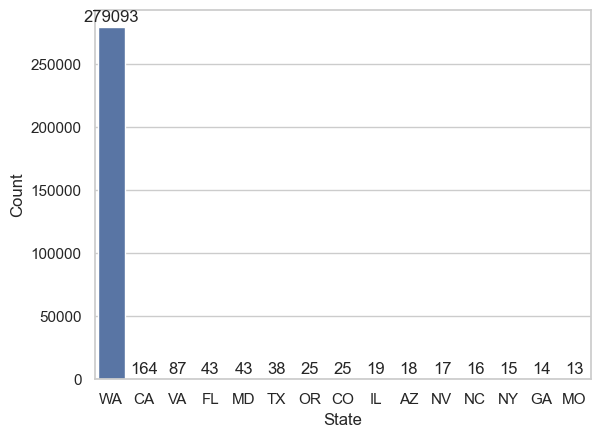

In [4]:
top_fifteen_states = duckdb.sql("""
                                SELECT State, COUNT(*) AS Count from df
                                GROUP BY State
                                ORDER BY Count DESC
                                LIMIT 15
                                """).df()

sns.set_theme(style="whitegrid")
plot = sns.barplot(top_fifteen_states, x='State', y='Count')
# adding labels to each bar, more info found here: https://www.geeksforgeeks.org/python/how-to-show-values-on-seaborn-barplot/
for container in plot.containers:
    plot.bar_label(container, padding=2)
    
plt.show()

Using the above plot, we can see that the Washington State has the highest amount of Electric Vehicles registered. 

In order to see the count of EVs in other states, we will have to limit one of the plots to the fourteen States besides Washington State seen in the above bar chart.

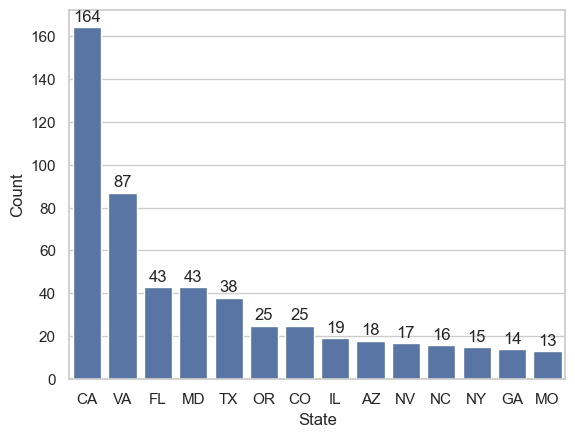

In [5]:
plot = sns.barplot(top_fifteen_states[1:], x='State', y='Count')
# adding labels to each bar, more info found here: https://www.geeksforgeeks.org/python/how-to-show-values-on-seaborn-barplot/
for container in plot.containers:
    plot.bar_label(container, padding=2)
    
plt.show()

From the above bar charts, we can see that...

2) To further this exploration, which states prefer PHEVs versus BEVs in the United States?

In [6]:
electric_types = duckdb.sql("""
                            SELECT State, MODE("Electric Vehicle Type") AS Type from df
                            GROUP BY State
                            """).df()
electric_types.head()

,State,Type
0,VA,Battery Electric (BEV)
1,DC,Battery Electric (BEV)
2,CT,Battery Electric (BEV)
3,NE,Battery Electric (BEV)
4,IN,Battery Electric (BEV)


We can also plot the distribution of the vehicles using plotly, as can be seen here in their documentation: https://plotly.com/python/choropleth-maps/

In [7]:
fig = px.choropleth(data_frame=electric_types, locations='State', locationmode="USA-states", color='Type', scope='usa')
fig

3) Which ten counties, cities, and states have the highest amount of EVs, split by PHEVs and BEVs?
First, let's see the top ten counties and cities with the highest amount of EVs:

In [8]:
top_counties_cities = duckdb.sql("""
                            SELECT County, City, State, COUNT(*) AS Count from df
                            GROUP BY County, City, State
                            ORDER BY Count DESC
                            LIMIT 10
                            """).df()
top_counties_cities

,County,City,State,Count
0,King,Seattle,WA,43250
1,King,Bellevue,WA,13683
2,Clark,Vancouver,WA,10395
3,King,Redmond,WA,9606
4,King,Kirkland,WA,7978
5,King,Sammamish,WA,7798
6,King,Renton,WA,7647
7,Snohomish,Bothell,WA,7273
8,Thurston,Olympia,WA,6508
9,Pierce,Tacoma,WA,6072


Since the state in the above table is always Washington, we can leave the State out in the following step.

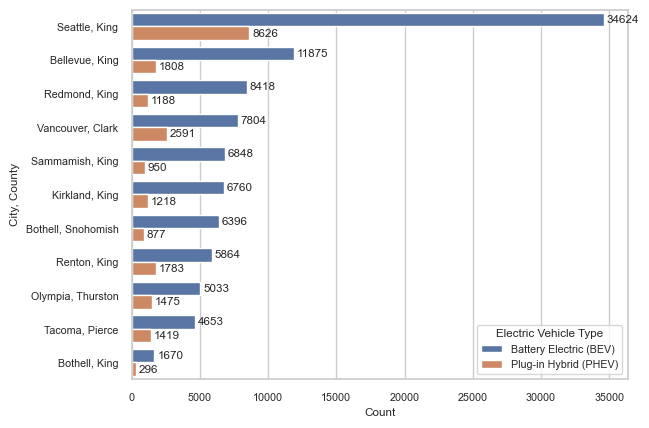

In [9]:
# Now, we use IN with the counties we found in the first step like so: https://stackoverflow.com/a/29749286
top_counties = top_counties_cities['County'].tolist()
top_cities = top_counties_cities['City'].tolist()

top_evs_county_city = duckdb.sql(f"""
                            SELECT County, City, "Electric Vehicle Type", COUNT(*) AS Count from df
                            WHERE County IN {top_counties} AND City IN {top_cities}
                            GROUP BY County, City, "Electric Vehicle Type"
                            ORDER BY Count DESC
                            """).df()

sns.set_theme(style="whitegrid", font_scale=0.7)
top_evs_county_city["City, County"] = top_evs_county_city["City"] + ", " + top_evs_county_city["County"] 
plot = sns.barplot(top_evs_county_city, x='Count', y='City, County', hue="Electric Vehicle Type")
# adding labels to each bar, more info found here: https://www.geeksforgeeks.org/python/how-to-show-values-on-seaborn-barplot/
for container in plot.containers:
    plot.bar_label(container, padding=2)
    
plt.show()

From the above graph, we can see...

4) What are the counties and states with the most EVs?

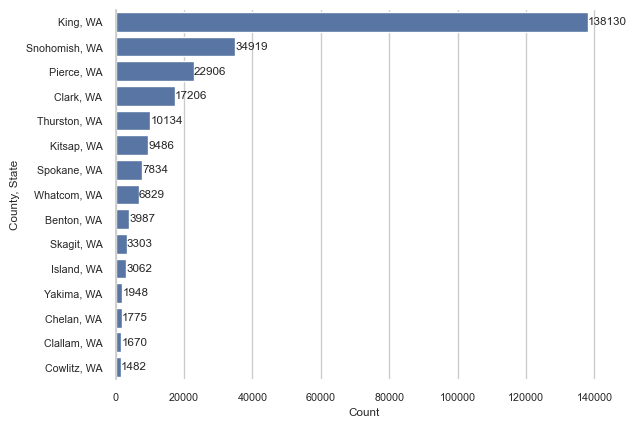

In [ ]:
pop_county = duckdb.sql("""
                    SELECT County, State, COUNT(County) AS Count FROM df
                    GROUP BY County, State
                    ORDER BY Count DESC
                    LIMIT 15
                    """).df()
pop_county["County, State"] = pop_county["County"] + ", " + pop_county["State"]
plot = sns.barplot(pop_county, x="Count", y="County, State")
for container in plot.containers:
    plot.bar_label(container)
sns.despine(bottom=True)
plt.show()

How does the count of EVs model years change over time in the top 10 counties?

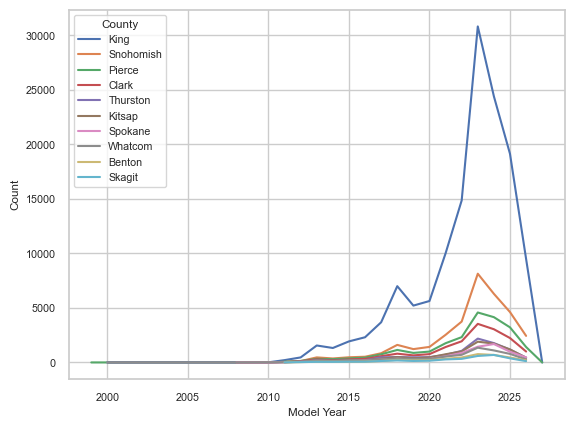

In [10]:
top_10_counties = duckdb.sql("""
                            SELECT County, COUNT(*) AS Count from df
                            GROUP BY County
                            ORDER BY Count DESC
                            LIMIT 10
                            """).df()
county_list = top_10_counties['County'].tolist()

county_vs_year = duckdb.sql(f"""
                            SELECT County, "Model Year", COUNT(*) AS Count from df
                            WHERE County IN {county_list}
                            GROUP BY County, "Model Year"
                            ORDER BY Count DESC
                            """).df()
plot = sns.lineplot(county_vs_year, x='Model Year', y='Count', hue='County')


4) What are the top ten most popular brands of Electric Vehicles?

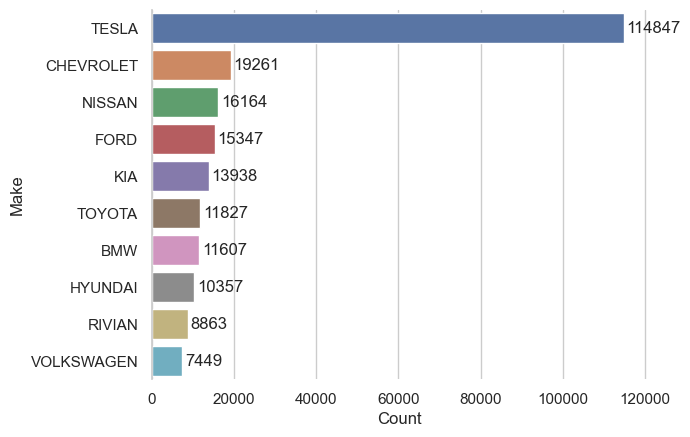

In [11]:
top_10_makes = duckdb.sql("""
                            SELECT Make, COUNT(*) AS Count from df
                            GROUP BY Make
                            ORDER BY Count DESC
                            LIMIT 10
                            """).df()
plt.rcdefaults()
sns.set_theme(style="whitegrid")
plot = sns.barplot(top_10_makes, x='Count', y='Make', hue='Make')

# adding labels to each bar, more info found here: https://www.geeksforgeeks.org/python/how-to-show-values-on-seaborn-barplot/
for container in plot.containers:
    plot.bar_label(container, padding=2)
sns.despine(bottom=True)
plt.show()


6) How have the number of PHEVs and BEVs changed over the years?

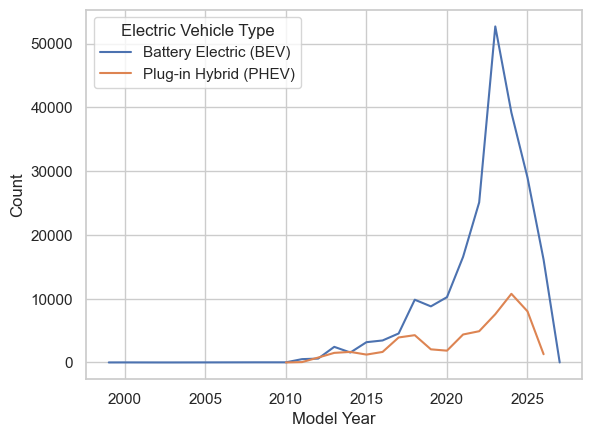

In [ ]:
yearly_dist = duckdb.sql("""
                    SELECT "Electric Vehicle Type", "Model Year", COUNT(Model) AS Count FROM df
                    GROUP BY "Electric Vehicle Type", "Model Year"
                    ORDER BY Count DESC
                    """).df()
sns.lineplot(yearly_dist, x="Model Year", y='Count', hue="Electric Vehicle Type")
plt.show()

7) How does Minimum and Maximum Electric Ranges change depending on brands?

8) How have Electric Ranges changed over the years?